# SMETANA Interaction Analysis - LAB Legume Fermentation

**Project:** Cooperative Tradeoff Analysis of Consortia for Plant-Based Fermentation  

Community construction, structural validation and interaction scoring for the *L.plantarum* WCFS1 + *L.mesenteroides* ATCC 8293 consortium
across six legume medium scenarios (chickpea and fava bean × min/med/max).

**Note on `harmonize_koduru_ids`:** The Koduru model uses hyphens in some metabolite IDs (`gln-L_e`), encoded by reframed as `__45__`. Without harmonization, SMETANA creates duplicate pool reactions and the legume medium never opens the `__45__` pools.
*L.mesenteroides* loses access to ~115 nutrients and cannot grow. `harmonize_koduru_ids` renames the IDs in memory before community construction.

## 1. Setup

Imports, Gurobi license configuration, and model paths. `legume_medium1_v2` supplies the efficiency fractions and exchange mapping used throughout this notebook.

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

_lic = os.path.expanduser('~/gurobi.lic')
if os.path.exists(_lic):
    os.environ['GRB_LICENSE_FILE'] = _lic

from reframed import load_cbmodel, FBA
from smetana.interface import Community, Environment
from smetana.smetana import mip_score, mro_score, sc_score, mu_score, mp_score
from mpl_toolkits.axes_grid1 import make_axes_locatable

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from legume_medium1_v2 import *

MODEL_LP = '../models/curated/iLP728_curated_v2.xml'
MODEL_LM = '../models/curated/Koduru2022_curated_v2.xml'

for p in [MODEL_LP, MODEL_LM]:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

## 2. Community Construction

The Koduru model is harmonized before the merge to eliminate `__45__` IDs. The community is built with `merge_extracellular_compartments=False` so each organism retains its own exchanges in the merged model — a prerequisite for SMETANA to compute MIP and MRO correctly.

In [2]:
lp = load_cbmodel(MODEL_LP, flavor='bigg')
lm_raw = load_cbmodel(MODEL_LM, flavor='bigg')
lm, n_harmonized = harmonize_koduru_ids(lm_raw)
print(f'Koduru: {n_harmonized} IDs renamed (__45__ → BiGG standard)')

community = Community(
    community_id='LAB_legume',
    models=[lp, lm],
    copy_models=True,
    merge_extracellular_compartments=False,
    create_biomass=True,
    interacting=True,
)
merged = community.merged

comm_growth_id = next(
    (r for r in merged.reactions if 'community' in r.lower() and 'growth' in r.lower()),
    None
)
if comm_growth_id is None:
    raise RuntimeError('R_Community_Growth not found in merged model.')

ORG_LP = next(o for o in community.organisms if 'plantarum' in o.lower() or 'WCFS' in o)
ORG_LM = next(o for o in community.organisms if 'LeMt' in o or 'mesenteroides' in o.lower())

print(f'\nCommunity growth reaction : {comm_growth_id}')
print(f'L. plantarum organism ID  : {ORG_LP}')
print(f'L. mesenteroides org ID   : {ORG_LM}')
print(f'Merged model              : {len(merged.reactions)} reactions | {len(merged.metabolites)} metabolites')

Koduru: 115 IDs renamed (__45__ → BiGG standard)

Community growth reaction : R_Community_Growth
L. plantarum organism ID  : M_Lactobacillus_plantarum_WCFS1
L. mesenteroides org ID   : M_LeMt
Merged model              : 2071 reactions | 1771 metabolites


In [3]:
# Demonstrate why harmonize_koduru_ids is required:
# load Lm without harmonisation and show duplicate pools
lm_test = load_cbmodel(MODEL_LM, flavor='bigg')
comm_raw = Community(
    community_id='LAB_legume_raw',
    models=[load_cbmodel(MODEL_LP, flavor='bigg'), lm_test],
    copy_models=True, merge_extracellular_compartments=False,
    create_biomass=True, interacting=True,
)
pools_45  = [r for r in comm_raw.merged.reactions if r.endswith('_pool') and '__45__' in r]
pools_std = [r for r in comm_raw.merged.reactions if r.endswith('_pool') and '__45__' not in r]

print('Pools in merged WITHOUT harmonisation:')
print(f'  Standard (BiGG):   {len(pools_std)}')
print(f'  Duplicate __45__:  {len(pools_45)}')
print()
print('Examples of duplicate pools (never opened by legume medium):')
for p in sorted(pools_45)[:5]:
    print(f'  {p}')

# Confirm: Lm cannot grow without harmonisation
env_test, _ = build_smetana_environment_(
    comm_raw, chickpea_med, EFICIENCIA_LP, verbose=False
)
env_test.apply(comm_raw.merged, exclusive=True, inplace=True)
print()
for org_id in comm_raw.organisms:
    sol = FBA(comm_raw.merged, objective=f'Sink_biomass_{org_id}')
    mu  = sol.fobj if sol and sol.fobj else 0.0
    tag = 'GROWS' if mu > 1e-6 else '✗ NO GROWTH — __45__ pools closed'
    print(f'  {org_id}: μ = {mu:.4f}  [{tag}]')

Pools in merged WITHOUT harmonisation:
  Standard (BiGG):   165
  Duplicate __45__:  32

Examples of duplicate pools (never opened by legume medium):
  R_EX_M_2hxic__45__L_e_pool
  R_EX_M_ala__45__D_e_pool
  R_EX_M_ala__45__L_e_pool
  R_EX_M_arab__45__L_e_pool
  R_EX_M_arg__45__L_e_pool

Set parameter Username
Set parameter LicenseID to value 2818537
Academic license - for non-commercial use only - expires 2027-05-05
  M_Lactobacillus_plantarum_WCFS1: μ = 0.4751  [GROWS]
  M_LeMt: μ = 0.0777  [GROWS]


## 3. Structural Validation

Before applying any medium, verify:
- each organism's exchanges exist in the merged model with the expected IDs;
- all compounds in the legume maps have a corresponding pool reaction;
- the biomass → Sink → R_Community_Growth chain is intact;
- no residual `__45__` pools remain after harmonization.


In [4]:
ex_lp = community.organisms_exchange_reactions.get(ORG_LP, set())
ex_lm = community.organisms_exchange_reactions.get(ORG_LM, set())

print(f'Exchanges L.plantarum: {len(ex_lp)}')
print(f'Exchanges L.mesenteroides: {len(ex_lm)}')

def extract_met_id(ex_id, org_id):
    s = ex_id.replace('R_EX_', '')
    s = s.replace(f'_{org_id}', '')
    return s

mets_lp = {extract_met_id(r, ORG_LP): r for r in ex_lp}
mets_lm = {extract_met_id(r, ORG_LM): r for r in ex_lm}

print('\nFirst 10 exchanges — Lp:')
for met, rxn in list(mets_lp.items())[:10]:
    print(f'  {met:<30} → {rxn}')

print('\nFirst 10 exchanges — Lm:')
for met, rxn in list(mets_lm.items())[:10]:
    print(f'  {met:<30} → {rxn}')

Exchanges L.plantarum: 118
Exchanges L.mesenteroides: 132

First 10 exchanges — Lp:
  pydxn_e                        → R_EX_pydxn_e_M_Lactobacillus_plantarum_WCFS1
  melib_e                        → R_EX_melib_e_M_Lactobacillus_plantarum_WCFS1
  na1_e                          → R_EX_na1_e_M_Lactobacillus_plantarum_WCFS1
  galt_e                         → R_EX_galt_e_M_Lactobacillus_plantarum_WCFS1
  ala__L_e                       → R_EX_ala__L_e_M_Lactobacillus_plantarum_WCFS1
  2mbald_e                       → R_EX_2mbald_e_M_Lactobacillus_plantarum_WCFS1
  glycogen_e                     → R_EX_glycogen_e_M_Lactobacillus_plantarum_WCFS1
  glyc_e                         → R_EX_glyc_e_M_Lactobacillus_plantarum_WCFS1
  fuc__L_e                       → R_EX_fuc__L_e_M_Lactobacillus_plantarum_WCFS1
  no3_e                          → R_EX_no3_e_M_Lactobacillus_plantarum_WCFS1

First 10 exchanges — Lm:
  btd__RR_e                      → R_EX_btd__RR_e_M_LeMt
  2mbol_e                        

In [5]:
pool_map = {}
for r_id in merged.reactions:
    if not r_id.endswith('_pool'):
        continue
    if r_id.startswith('R_EX_M_'):
        met_id = r_id[7:-5]
    elif r_id.startswith('R_EX_'):
        met_id = r_id[5:-5]
    else:
        continue
    pool_map[met_id] = r_id

print(f'Total pool reactions: {len(pool_map)}')

pools_45_post = [r for r in pool_map.values() if '__45__' in r]
if pools_45_post:
    print(f'\nWARNING: {len(pools_45_post)} residual __45__ pools after harmonization:')
    for p in sorted(pools_45_post)[:10]:
        print(f'  {p}')
else:
    print('  No __45__ pools — harmonization complete.')

# iLP728 coverage
EXPECTED_ABSENT_LP = {'palmítico', 'esteárico', 'oleico'}
sem_pool_lp = []
for composto, ex_id in sorted(mapa_ilp728.items()):
    if ex_id is None or composto in EXPECTED_ABSENT_LP:
        continue
    met_id = ex_id.replace('EX_', '')
    if pool_map.get(met_id) is None:
        sem_pool_lp.append(composto)

if sem_pool_lp:
    print(f'\nUnexpected missing pools — iLP728: {sem_pool_lp}')
else:
    print('All iLP728 map compounds have pool reactions.')

# Koduru coverage
EXPECTED_ABSENT_LM = {'magnesio'}
sem_pool_lm = []
for composto, ex_id in sorted(mapa_koduru.items()):
    if ex_id is None or composto in EXPECTED_ABSENT_LM:
        continue
    met_id = ex_id.replace('EX_', '')
    if pool_map.get(met_id) is None:
        sem_pool_lm.append(composto)

if sem_pool_lm:
    print(f'Unexpected missing pools — Koduru: {sem_pool_lm}')
else:
    print('All Koduru map compounds have pool reactions.')

Total pool reactions: 171
  No __45__ pools — harmonization complete.
All iLP728 map compounds have pool reactions.
All Koduru map compounds have pool reactions.


In [6]:
print('=== Biomass chain ===\n')
for org_id, bio_rxn_id in community.organisms_biomass_reactions.items():
    bio_rxn = merged.reactions[bio_rxn_id]
    bio_mets_produced = [m for m, s in bio_rxn.stoichiometry.items() if s > 0]
    sink_id = f'Sink_biomass_{org_id}'
    print(f'Organism: {org_id}')
    print(f'  Biomass reaction : {bio_rxn_id}  (lb={bio_rxn.lb:.4f})')
    print(f'  Biomass products : {bio_mets_produced}')
    if sink_id in merged.reactions:
        sink = merged.reactions[sink_id]
        print(f'  Sink reaction    : {sink_id}  (lb={sink.lb}, ub={sink.ub})')
    else:
        print(f'  ERROR: {sink_id} not found!')
    print()

cg = merged.reactions[comm_growth_id]
print(f'Community growth: {comm_growth_id}')
print(f'  Stoichiometry : {dict(cg.stoichiometry)}')
print(f'  Objective     : {cg.objective}')

=== Biomass chain ===

Organism: M_Lactobacillus_plantarum_WCFS1
  Biomass reaction : R_biomass_LPL_RETB_t576_NoATP_M_Lactobacillus_plantarum_WCFS1  (lb=0.0004)
  Biomass products : ['Biomass_M_Lactobacillus_plantarum_WCFS1']
  Sink reaction    : Sink_biomass_M_Lactobacillus_plantarum_WCFS1  (lb=0.0, ub=inf)

Organism: M_LeMt
  Biomass reaction : R_biomass_M_LeMt  (lb=0.0000)
  Biomass products : ['M_adp_c_M_LeMt', 'M_h_c_M_LeMt', 'M_pi_c_M_LeMt', 'Biomass_M_LeMt']
  Sink reaction    : Sink_biomass_M_LeMt  (lb=0.0, ub=inf)

Community growth: R_Community_Growth
  Stoichiometry : {'Biomass_M_Lactobacillus_plantarum_WCFS1': -1, 'Biomass_M_LeMt': -1}
  Objective     : 1.0


In [7]:
checks = [
    ('Community built (2 organisms)',    len(community.organisms) == 2),
    ('R_Community_Growth found',         comm_growth_id is not None),
    ('Sink_biomass Lp present',          f'Sink_biomass_{ORG_LP}' in merged.reactions),
    ('Sink_biomass Lm present',          f'Sink_biomass_{ORG_LM}' in merged.reactions),
    ('Pool reactions present',           len(pool_map) > 0),
    ('No residual __45__ pools',         len(pools_45_post) == 0),
    ('iLP728 map pool coverage OK',      len(sem_pool_lp) == 0),
    ('Koduru map pool coverage OK',      len(sem_pool_lm) == 0),
]

print('=== VALIDATION SUMMARY ===\n')
failures = []
for description, result in checks:
    symbol = '✓' if result else '✗'
    print(f'  [{symbol}]  {description}')
    if not result:
        failures.append(description)

print()
if not failures:
    print('All checks passed. Proceeding to SMETANA.')
else:
    print(f'{len(failures)} check(s) failed — resolve before proceeding:')
    for f in failures:
        print(f'  - {f}')
    raise RuntimeError('Validation failed.')

=== VALIDATION SUMMARY ===

  [✓]  Community built (2 organisms)
  [✓]  R_Community_Growth found
  [✓]  Sink_biomass Lp present
  [✓]  Sink_biomass Lm present
  [✓]  Pool reactions present
  [✓]  No residual __45__ pools
  [✓]  iLP728 map pool coverage OK
  [✓]  Koduru map pool coverage OK

All checks passed. Proceeding to SMETANA.


In [8]:
def _fresh_community():
    """Load models from disk and build a clean community.
    Call before each SMETANA score to avoid residual bound modifications.
    """
    lp_ = load_cbmodel(MODEL_LP, flavor='bigg')
    lm_ = load_cbmodel(MODEL_LM, flavor='bigg')
    lm_, _ = harmonize_koduru_ids(lm_)
    return Community(
        community_id='LAB_legume',
        models=[lp_, lm_],
        copy_models=True,
        merge_extracellular_compartments=False,
        create_biomass=True,
        interacting=True,
    )

# Compound → met_id mapping (shared between sections 6 and 7)
mapa_met = {}
for mapa in [mapa_ilp728, mapa_koduru]:
    for composto, ex_id in mapa.items():
        if ex_id is None or composto in mapa_met:
            continue
        met_id = ex_id.replace('EX_', '').replace('R_EX_', '')
        mapa_met[composto] = met_id

def aplicar_bounds_organismo(merged_model, composicao, org_id, eficiencia):
    """Apply organism-specific composition bounds to individual exchange reactions."""
    for composto, C_mgkg in composicao.items():
        if composto not in mapa_met or composto not in MW:
            continue
        met_id = mapa_met[composto]
        eff    = eficiencia.get(composto, 1.0)
        bound  = calcular_bound(C_mgkg, MW[composto], efficiency=eff)
        rxn_id = f'R_EX_{met_id}_{org_id}'
        if rxn_id not in merged_model.reactions:
            continue
        current_lb = merged_model.reactions[rxn_id].lb
        merged_model.reactions[rxn_id].lb = max(bound, current_lb)

## 4. Baseline Growth (complete medium)

`Environment.complete()` opens all pool reactions at `max_uptake=10 mmol/gDW/h`. This is not the legume medium — it is a sanity check confirming that both models grow in the merged model before nutritional constraints are applied.

In [9]:
comm_baseline = _fresh_community()
merged_baseline = comm_baseline.merged
env_default = Environment.complete(merged_baseline, max_uptake=10.0)
env_default.apply(merged_baseline, exclusive=True, inplace=True)

print('Individual growth — complete medium (max_uptake=10 mmol/gDW/h):')
print('-' * 55)
all_grow = True
for org_id, bio_rxn_id in comm_baseline.organisms_biomass_reactions.items():
    sol = FBA(merged_baseline, objective=bio_rxn_id)
    mu  = sol.fobj if sol.fobj is not None else 0.0
    tag = 'GROWS' if mu > 1e-6 else 'NO GROWTH'
    if mu <= 1e-6:
        all_grow = False
    print(f'  {org_id}')
    print(f'    μ = {mu:.4f} h⁻¹  →  {tag}')

if not all_grow:
    raise RuntimeError('At least one organism does not grow on complete medium.')

Individual growth — complete medium (max_uptake=10 mmol/gDW/h):
-------------------------------------------------------
  M_Lactobacillus_plantarum_WCFS1
    μ = 15.8203 h⁻¹  →  GROWS
  M_LeMt
    μ = 48.3944 h⁻¹  →  GROWS


## 5. Nutritional Scenarios & EFICIENCIA_MAX

Six scenarios are tested: `chickpea × {min, med, max}` and `fava bean × {min, med, max}`. The community-level uptake bound
uses `EFICIENCIA_MAX` - the maximum efficiency between *L.plantarum* and *L.mesenteroides* per compound. For stachyose (eff_lp=0, eff_lm=0.4), max(0, 0.4)=0.4
opens the pool for the consortium, allowing *L.mesenteroides* access. Using EFICIENCIA_LP alone would keep the bound at 0 and close the
substrate even though it is available to *L.mesenteroides*.

In [10]:
all_compounds = set(EFICIENCIA_LP) | set(EFICIENCIA_LM)
EFICIENCIA_MAX = {
    c: max(EFICIENCIA_LP.get(c, 0.0), EFICIENCIA_LM.get(c, 0.0))
    for c in all_compounds
}

diffs = {
    c: (EFICIENCIA_LP.get(c, 0.0), EFICIENCIA_LM.get(c, 0.0), EFICIENCIA_MAX[c])
    for c in sorted(all_compounds)
    if EFICIENCIA_LP.get(c, 0.0) != EFICIENCIA_LM.get(c, 0.0)
}
if diffs:
    print(f'{"Compound":<20} {"Lp":>6} {"Lm":>6} {"Max":>6}')
    print('-' * 38)
    for c, (lp_eff, lm_eff, max_eff) in diffs.items():
        print(f'  {c:<20} {lp_eff:>6.2f} {lm_eff:>6.2f} {max_eff:>6.2f}')

SCENARIOS = {
    'cp_min': chickpea_min, 'cp_med': chickpea_med, 'cp_max': chickpea_max,
    'fb_min': favabean_min, 'fb_med': favabean_med, 'fb_max': favabean_max,
}
SCENARIO_LABELS = {
    'cp_min': 'Chickpea (min)', 'cp_med': 'Chickpea (med)', 'cp_max': 'Chickpea (max)',
    'fb_min': 'Fava Bean (min)', 'fb_med': 'Fava Bean (med)', 'fb_max': 'Fava Bean (max)',
}

print('\nBuilding environments for 6 scenarios...')
environments = {}
env_logs     = {}
for scenario_id, composicao in SCENARIOS.items():
    env, log = build_smetana_environment_(
        community, composicao, EFICIENCIA_MAX, verbose=False
    )
    environments[scenario_id] = env
    env_logs[scenario_id]     = log
    print(f'  {SCENARIO_LABELS[scenario_id]:<20} {len(log)} bounds applied')

print('\nEnvironments ready.')

Compound                 Lp     Lm    Max
--------------------------------------
  raffinose              0.55   0.60   0.60
  stachyose              0.00   0.40   0.40

Building environments for 6 scenarios...
  Chickpea (min)       38 bounds applied
  Chickpea (med)       43 bounds applied
  Chickpea (max)       43 bounds applied
  Fava Bean (min)      41 bounds applied
  Fava Bean (med)      41 bounds applied
  Fava Bean (max)      41 bounds applied

Environments ready.


## 6. Individual Growth per Scenario

Both organisms are tested individually in each scenario to confirm growth before running SMETANA scores. `min_growth` is set dynamically
to 10% of the slower organism per scenario — a conservative threshold that calibrates SMETANA's minimum growth requirement to the effective
medium rather than using a fixed value.

In [11]:
def testar_crescimento_cenario(env, composicao, scenario_label):
    comm_    = _fresh_community()
    merged_  = comm_.merged
    env.apply(merged_, exclusive=True, inplace=True)
    aplicar_bounds_organismo(merged_, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(merged_, composicao, ORG_LM, EFICIENCIA_LM)
    resultados = {}
    for org_id, bio_rxn in comm_.organisms_biomass_reactions.items():
        sol = FBA(merged_, objective=bio_rxn)
        mu  = sol.fobj if sol.fobj is not None else 0.0
        resultados[org_id] = {'mu': mu, 'cresce': mu > 1e-6}
    return resultados

print('Individual growth per scenario')
print('=' * 70)

growth_results         = {}
min_growth_per_scenario = {}

for scenario_id, env in environments.items():
    res   = testar_crescimento_cenario(env, SCENARIOS[scenario_id], SCENARIO_LABELS[scenario_id])
    growth_results[scenario_id] = res
    mus   = [v['mu'] for v in res.values()]
    min_g = 0.1 * min(mus) if all(mu > 1e-6 for mu in mus) else 1e-4
    min_growth_per_scenario[scenario_id] = min_g
    print(f'\n{SCENARIO_LABELS[scenario_id]}')
    for org_id, v in res.items():
        tag = 'Growth' if v['cresce'] else 'No growth'
        print(f'  {org_id:<50} μ = {v["mu"]:.5f} h⁻¹  →  {tag}')
    print(f'  min_growth for SMETANA: {min_g:.6f} h⁻¹')

rows = []
for sid, res in growth_results.items():
    lp_id = next(k for k in res if 'plantarum' in k.lower())
    lm_id = next(k for k in res if 'LeMt' in k or 'mesenteroides' in k.lower())
    rows.append({
        'Scenario'   : SCENARIO_LABELS[sid],
        'μ Lp (h⁻¹)': f"{res[lp_id]['mu']:.5f}",
        'μ Lm (h⁻¹)': f"{res[lm_id]['mu']:.5f}",
        'min_growth' : f"{min_growth_per_scenario[sid]:.6f}",
        'L.plantarum grows'   : res[lp_id]['cresce'],
        'L.mesenteroides grows'   : res[lm_id]['cresce'],
    })
print('\n')
print(pd.DataFrame(rows).to_string(index=False))

Individual growth per scenario

Chickpea (min)
  M_Lactobacillus_plantarum_WCFS1                    μ = 0.38561 h⁻¹  →  Growth
  M_LeMt                                             μ = 0.04783 h⁻¹  →  Growth
  min_growth for SMETANA: 0.004783 h⁻¹

Chickpea (med)
  M_Lactobacillus_plantarum_WCFS1                    μ = 0.47507 h⁻¹  →  Growth
  M_LeMt                                             μ = 0.07773 h⁻¹  →  Growth
  min_growth for SMETANA: 0.007773 h⁻¹

Chickpea (max)
  M_Lactobacillus_plantarum_WCFS1                    μ = 0.56453 h⁻¹  →  Growth
  M_LeMt                                             μ = 0.10763 h⁻¹  →  Growth
  min_growth for SMETANA: 0.010763 h⁻¹

Fava Bean (min)
  M_Lactobacillus_plantarum_WCFS1                    μ = 0.06822 h⁻¹  →  Growth
  M_LeMt                                             μ = 0.13453 h⁻¹  →  Growth
  min_growth for SMETANA: 0.006822 h⁻¹

Fava Bean (med)
  M_Lactobacillus_plantarum_WCFS1                    μ = 0.20466 h⁻¹  →  Growth
  M_LeMt   

## 7. SMETANA Scores

| Score | What it measures |
|-------|-----------------|
| MIP | Number of compounds each organism cannot obtain without its partner |
| MRO | Overlap of minimum resource requirements (0=no competition, 1=total) |
| SC  | Coupling frequency — probability of growth dependency |
| MUS  | Probability of uptake of compounds produced by the partner |
| MPS  | Compounds each organism can structurally secrete that are not already part of the applied medium |

`min_growth` is set dynamically per scenario (Section 6). Each score uses a fresh community to avoid residual bound modifications.

The 64–66 metabolites with MPS (filtered) = 1.0 in every scenario are fermentation byproducts and biosynthetic intermediates the model can
produce in principle (lactate, acetate, ethanol, glycogen, dextran and the Strecker/Ehrlich aldehydes and acids among them) — not evidence that they are secreted under realistic, growth-constrained legume fermentation conditions. 

**SC=1.0 for *L.plantarum* is an artefact, not a real dependency:** forcing all *L.mesenteroides* reactions to zero leaves *L.plantarum* growth unchanged at 0.4751 h⁻¹ vs. the solo baseline of 0.47507 h⁻¹ in the same scenario. The two-species binarity explained above accounts for the *lack of graded nuance* in this score, but not for the specific value being wrong — that is a separate, score-construction limitation: `sc_score` only tests feasibility at an artificially low `min_growth` threshold (0.007773 h⁻¹ here, 10% of the slower organism) via a sampled MILP donor search, which does not verify whether the species can reach its actual optimal growth rate without the partner.

In [12]:
def run_smetana_scenario(env, composicao, min_growth, scenario_label):
    print(f'\n{scenario_label}  (min_growth={min_growth:.6f})')

    print('  [MIP]', end=' ', flush=True)
    c = _fresh_community()
    env.apply(c.merged, exclusive=True, inplace=True)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LM, EFICIENCIA_LM)
    mip = mip_score(c, environment=env, min_growth=min_growth, verbose=False)
    print(f'MIP = {mip[0]}')

    print('  [MRO]', end=' ', flush=True)
    c = _fresh_community()
    env.apply(c.merged, exclusive=True, inplace=True)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LM, EFICIENCIA_LM)
    mro = mro_score(c, environment=env, min_growth=min_growth, verbose=False)
    print(f'MRO = {mro[0]:.4f}')

    print('  [SC] ', end=' ', flush=True)
    c = _fresh_community()
    env.apply(c.merged, exclusive=True, inplace=True)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LM, EFICIENCIA_LM)
    sc = sc_score(c, environment=env, min_growth=min_growth, verbose=False)
    print('done')

    print('  [MU] ', end=' ', flush=True)
    c = _fresh_community()
    env.apply(c.merged, exclusive=True, inplace=True)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LM, EFICIENCIA_LM)
    mu = mu_score(c, environment=env, min_growth=min_growth, verbose=False)
    print('done')

    print('  [MP] ', end=' ', flush=True)
    c = _fresh_community()
    env.apply(c.merged, exclusive=True, inplace=True)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LP, EFICIENCIA_LP)
    aplicar_bounds_organismo(c.merged, composicao, ORG_LM, EFICIENCIA_LM)
    mp = mp_score(c, environment=env)
    print('done')

    return {'mip': mip, 'mro': mro, 'sc': sc, 'mu': mu, 'mp': mp}

print('SMETANA scores — 6 scenarios:')


smetana_results = {}
for scenario_id, env in environments.items():
    min_g  = min_growth_per_scenario[scenario_id]
    scores = run_smetana_scenario(
        env, SCENARIOS[scenario_id], min_g, SCENARIO_LABELS[scenario_id]
    )
    smetana_results[scenario_id] = scores

SMETANA scores — 6 scenarios:

Chickpea (min)  (min_growth=0.004783)
  [MIP] MIP = 6
  [MRO] MRO = 0.2857
  [SC]  done
  [MU]  done
  [MP]  done

Chickpea (med)  (min_growth=0.007773)
  [MIP] MIP = 10
  [MRO] MRO = 0.3529
  [SC]  done
  [MU]  done
  [MP]  done

Chickpea (max)  (min_growth=0.010763)
  [MIP] MIP = 10
  [MRO] MRO = 0.4706
  [SC]  done
  [MU]  done
  [MP]  done

Fava Bean (min)  (min_growth=0.006822)
  [MIP] MIP = 5
  [MRO] MRO = 0.3750
  [SC]  done
  [MU]  done
  [MP]  done

Fava Bean (med)  (min_growth=0.020466)
  [MIP] MIP = 6
  [MRO] MRO = 0.5333
  [SC]  done
  [MU]  done
  [MP]  done

Fava Bean (max)  (min_growth=0.034110)
  [MIP] MIP = 5
  [MRO] MRO = 0.4000
  [SC]  done
  [MU]  done
  [MP]  done


In [13]:
sc_raw = smetana_results['cp_med']['sc']
print('SC raw — Chickpea (med)')
print('=' * 55)
for org, deps in sc_raw.items():
    org_label = 'L.plantarum' if 'plantarum' in org.lower() else 'L.mesenteroides'
    print(f'\n{org_label}:')
    if not deps:
        print('  No dependency detected (SC = 0.0)')
    else:
        for partner, freq in deps.items():
            partner_label = 'L.plantarum' if 'plantarum' in partner.lower() else 'L.mesenteroides'
            print(f'  Depends on {partner_label}: frequency = {freq:.4f}')

print()
print('Note: SC=1.0 for Lp reflects multiple obligate auxotrophies (Ile, Leu,Phe, Val, pantothenate, niacin)'
'— not inability to grow on complete medium.SC=0.0 for L.mesenteroides: L.mesenteroides never required L.plantarum across all MUS perturbations.')

print()
print('Verification (see following cell): forcing all L.mesenteroides reactions to zero,' \
'leaves L.plantarum growth unchanged (0.4751 vs 0.47507 h⁻¹, Chickpea med) — L.plantarum does not require L.mesenteroides to reach ' \
'this growth rate. SC=1.0 for L.plantarum here is a score-construction artefact: sc_score tests feasibility only at an artificially ' \
'low min_growth threshold (0.007773 h⁻¹, 10% of the slower organism) via a sampled MILP donor search, which does not verify whether ' \
'the species can reach its real growth rate without the partner. SC=0.0 for L.mesenteroides is unaffected by this issue.')

SC raw — Chickpea (med)

L.plantarum:
  Depends on L.mesenteroides: frequency = 1.0000

L.mesenteroides:
  Depends on L.plantarum: frequency = 0.0000

Note: SC=1.0 for Lp reflects multiple obligate auxotrophies (Ile, Leu,Phe, Val, pantothenate, niacin)— not inability to grow on complete medium.SC=0.0 for L.mesenteroides: L.mesenteroides never required L.plantarum across all MUS perturbations.

Verification (see following cell): forcing all L.mesenteroides reactions to zero,leaves L.plantarum growth unchanged (0.4751 vs 0.47507 h⁻¹, Chickpea med) — L.plantarum does not require L.mesenteroides to reach this growth rate. SC=1.0 for L.plantarum here is a score-construction artefact: sc_score tests feasibility only at an artificially low min_growth threshold (0.007773 h⁻¹, 10% of the slower organism) via a sampled MILP donor search, which does not verify whether the species can reach its real growth rate without the partner. SC=0.0 for L.mesenteroides is unaffected by this issue.


In [14]:
# Verification to see if L.plantarum growth requires L.mesenteroides as SC=1.0 implies
c_test = _fresh_community()
env  = environments['cp_med']
comp = chickpea_med
env.apply(c_test.merged, exclusive=True, inplace=True)
aplicar_bounds_organismo(c_test.merged, comp, ORG_LP, EFICIENCIA_LP)
aplicar_bounds_organismo(c_test.merged, comp, ORG_LM, EFICIENCIA_LM)

for r_id in c_test.organisms_reactions[ORG_LM]:
    if r_id != c_test.organisms_biomass_reactions[ORG_LM]:
        c_test.merged.reactions[r_id].lb = 0
        c_test.merged.reactions[r_id].ub = 0

sol_lm_off = FBA(c_test.merged, objective=c_test.organisms_biomass_reactions[ORG_LP])
mu_lp_solo = growth_results['cp_med'][ORG_LP]['mu']

print(f'L.plantarum growth, L.mesenteroides reactions forced to zero : {sol_lm_off.fobj:.5f} h⁻¹')
print(f'L.plantarum growth, L.mesenteroides present and active : {mu_lp_solo:.5f} h⁻¹')

L.plantarum growth, L.mesenteroides reactions forced to zero : 0.47507 h⁻¹
L.plantarum growth, L.mesenteroides present and active : 0.47507 h⁻¹


In [15]:
ARTEFACTOS = {
    'M_o2_e', 'M_h_e', 'M_h2o_e', 'M_methal_e', 'M_pi_e',
    'M_Mo2_e', 'M_Ni2_e', 'M_Co2_e',
    'M_cys__45__L_e', 'M_gln__45__L_e', 'M_ala__45__D_e',
    'M_lac__45__L_e', 'M_lac__45__D_e', 'M_ile__45__L_e',
    'M_leu__45__L_e', 'M_val__45__L_e', 'M_phe__45__L_e',
    'M_met__45__L_e', 'M_glu__45__L_e', 'M_his__45__L_e',
    'M_arg__45__L_e', 'M_tyr__45__L_e', 'M_trp__45__L_e',
    'M_asp__45__L_e', 'M_asn__45__L_e', 'M_ser__45__L_e',
    'M_thr__45__L_e', 'M_lys__45__L_e', 'M_pro__45__L_e',
    'M_2hxic__45__L_e', 'M_btd__45__RR_e', 'M_arab__45__L_e',
    'M_ascb__45__L_e', 'M_pnto__45__R_e', 'M_met__45__D_e',
    'M_ala__45__L_e', 'M_mal__45__L_e', 'M_xyl__45__D_e',
    'M_rib__45__D_e', 'M_ser__45__D_e',
}

def _summarise_scores(scores):
    mip = scores['mip']
    mro = scores['mro']
    sc  = scores['sc']
    mu  = scores['mu']
    mp  = scores['mp']

    sc_lp_lm, sc_lm_lp = 0.0, 0.0
    for org, deps in sc.items():
        if not deps:
            continue
        for dep, freq in deps.items():
            if 'plantarum' in org.lower():
                sc_lp_lm = max(sc_lp_lm, freq)
            else:
                sc_lm_lp = max(sc_lm_lp, freq)

    # MU and MP are dicts {organism: {metabolite: score}}. 'raw' and 'filtered' below count entries with score > 0 — these are 
    # counts of metabolites, not the scores themselves (MUS/MPS of SMETANA are probabilities 0-1 per metabolite)
    mu_raw_total  = sum(1 for mets in mu.values() if mets for v in mets.values() if v > 0)
    mu_filt_total = sum(
        1 for mets in mu.values() if mets
        for m, v in mets.items() if v > 0 and m not in ARTEFACTOS
    )
    mp_raw_total  = sum(1 for mets in mp.values() if mets for v in mets.values() if v > 0)
    mp_filt_total = sum(
        1 for mets in mp.values() if mets
        for m, v in mets.items() if v > 0 and m not in ARTEFACTOS
    )

    return {
        'MIP'          : mip[0],
        'MRO'          : round(mro[0], 4),
        'SC Lp→Lm'     : round(sc_lp_lm, 4),
        'SC Lm→Lp'     : round(sc_lm_lp, 4),
        'MU (filtered)': mu_filt_total,
        'MU (raw)'     : mu_raw_total,
        'MP (filtered)': mp_filt_total,
        'MP (raw)'     : mp_raw_total,
    }

rows = [
    {'Scenario': SCENARIO_LABELS[sid], **_summarise_scores(scores)}
    for sid, scores in smetana_results.items()
]
df_scores = pd.DataFrame(rows).set_index('Scenario')
df_main   = df_scores.drop(columns=['MU (raw)', 'MP (raw)'])

print('SMETANA scores summary:')
print('MIP/MRO/SC are scores 0-1 (or count, in the case of MIP) of SMETANA' \
'MUS and MPS in this table are counts of metabolites with a score > 0, not aggregated probabilities.')

print("\n")
print(df_main.to_string())
print()
for sid in smetana_results:
    mu_raw  = df_scores.loc[SCENARIO_LABELS[sid], 'MU (raw)']
    mu_filt = df_scores.loc[SCENARIO_LABELS[sid], 'MU (filtered)']
    mp_raw  = df_scores.loc[SCENARIO_LABELS[sid], 'MP (raw)']
    mp_filt = df_scores.loc[SCENARIO_LABELS[sid], 'MP (filtered)']
    print(f'  {SCENARIO_LABELS[sid]:<20}: MU {mu_raw} raw -> {mu_filt} filtered  ({mu_raw - mu_filt} removed)')
    print(f'  {"":<20}  MP {mp_raw} raw -> {mp_filt} filtered  ({mp_raw - mp_filt} removed)')

SMETANA scores summary:
MIP/MRO/SC are scores 0-1 (or count, in the case of MIP) of SMETANAMUS and MPS in this table are counts of metabolites with a score > 0, not aggregated probabilities.


                 MIP     MRO  SC Lp→Lm  SC Lm→Lp  MU (filtered)  MP (filtered)
Scenario                                                                      
Chickpea (min)     6  0.2857       1.0       0.0             20             64
Chickpea (med)    10  0.3529       1.0       0.0             35             65
Chickpea (max)    10  0.4706       1.0       0.0             30             66
Fava Bean (min)    5  0.3750       1.0       0.0             21             66
Fava Bean (med)    6  0.5333       1.0       0.0             32             66
Fava Bean (max)    5  0.4000       1.0       0.0             33             66

  Chickpea (min)      : MU 22 raw -> 20 filtered  (2 removed)
                        MP 65 raw -> 64 filtered  (1 removed)
  Chickpea (med)      : MU 39 raw -> 35 filtered  

## 8. Cross-Feeding Analysis

MUS raw includes artefacts:
- **Inorganic minerals** (`pi_e`, metals) — shared medium nutrients, not cell-to-cell transfer.
- **Residual `__45__` IDs** — only if harmonization was incomplete.

After filtering, metabolites are categorized for biological interpretation.

In [16]:
CATEGORIES = {
    'essential_aa'     : {'ile__L', 'leu__L', 'val__L', 'phe__L', 'trp__L',
                          'met__L', 'thr__L', 'lys__L', 'his__L', 'cys__L'},
    'nonessential_aa'  : {'glu__L', 'gln__L', 'asp__L', 'asn__L', 'pro__L',
                          'ser__L', 'ala__L', 'gly', 'tyr__L', 'arg__L'},
    'vitamins_cofactors': {'pnto__R', 'nac', 'nmn', 'btn', 'fol',
                            'ribflv', 'thm', 'pydxn', '4abz'},
    'organic_acids'    : {'etoh', 'lac__D', 'lac__L', 'ac', 'for',
                           'succ', 'actn__R', 'pyr'},
    'sugars_rfo'       : {'glc__D', 'fru', 'gal', 'sucr', 'malt',
                           'raffin', 'arab__L', 'man'},
    'off_flavors'      : {'hxa', 'hxol', 'nnl', 'nnol',
                           '2mbal', '3mbal', 'ibutld', 'pacald',
                           '2mba', '3mba', '2mpa', 'phenol'},
    'n_secondary'      : {'2hxic__L'},
    'nucleotides'      : {'ade', 'gua', 'ura', 'thymd', 'ins', 'hxan'},
}

def categorise(met_id_raw):
    met = met_id_raw.replace('M_', '').replace('_e', '')
    for cat, members in CATEGORIES.items():
        if met in members:
            return cat
    return 'other'

print('MUS filtered — all scenarios:')

for sid, scores in smetana_results.items():
    mu = scores['mu']
    print(f'\n{SCENARIO_LABELS[sid]}:')
    for org, mets in mu.items():
        if not mets:
            continue
        org_label = 'L.plantarum' if 'plantarum' in org.lower() else 'L.mesenteroides'
        filtered  = {m: v for m, v in mets.items() if v > 0 and m not in ARTEFACTOS}
        if not filtered:
            continue
        by_cat = {}
        for m, v in sorted(filtered.items(), key=lambda x: -x[1]):
            cat = categorise(m)
            by_cat.setdefault(cat, []).append(
                f"{m.replace('M_','').replace('_e','')}({v:.2f})"
            )
        print(f'  {org_label}:')
        for cat, items in by_cat.items():
            print(f'    [{cat}] {", ".join(items)}')

MUS filtered — all scenarios:

Chickpea (min):
  L.plantarum:
    [essential_aa] ile__L(1.00), met__L(1.00), phe__L(1.00), val__L(1.00), cys__L(0.99), leu__L(0.01)
    [vitamins_cofactors] nac(1.00)
    [nonessential_aa] tyr__L(1.00), glu__L(1.00), asp__L(0.99), ser__L(0.99), pro__L(0.01)
    [n_secondary] 2hxic__L(0.99)
    [sugars_rfo] arab__L(0.01)
  L.mesenteroides:
    [essential_aa] cys__L(1.00)
    [nonessential_aa] gln__L(1.00)
    [vitamins_cofactors] nmn(0.67), nac(0.33)
    [nucleotides] ade(0.33)
    [off_flavors] nnol(0.33)

Chickpea (med):
  L.plantarum:
    [essential_aa] ile__L(1.00), phe__L(1.00), val__L(1.00), leu__L(0.56), cys__L(0.55), met__L(0.53), thr__L(0.27)
    [vitamins_cofactors] pnto__R(1.00), nac(1.00)
    [nonessential_aa] pro__L(0.56), glu__L(0.46), asp__L(0.07), tyr__L(0.05), ser__L(0.03), gln__L(0.02)
    [n_secondary] 2hxic__L(0.44)
    [off_flavors] nnol(0.19), 2mba(0.08), 2mpa(0.04), 3mba(0.02)
    [sugars_rfo] sucr(0.12), arab__L(0.10), malt(0.08), 

In [17]:
print('MPS filtered — all scenarios (producer side')

for sid, scores in smetana_results.items():
    mp = scores['mp']
    print(f'\n{SCENARIO_LABELS[sid]}:')
    for org, mets in mp.items():
        if not mets:
            continue
        org_label = 'L.plantarum' if 'plantarum' in org.lower() else 'L.mesenteroides'
        filtered  = {m: v for m, v in mets.items() if v > 0 and m not in ARTEFACTOS}
        if not filtered:
            continue
        by_cat = {}
        for m, v in sorted(filtered.items(), key=lambda x: -x[1]):
            cat = categorise(m)
            by_cat.setdefault(cat, []).append(
                f"{m.replace('M_','').replace('_e','')}({v:.2f})"
            )
        print(f'  {org_label} (producer):')
        for cat, items in by_cat.items():
            print(f'    [{cat}] {", ".join(items)}')

MPS filtered — all scenarios (producer side

Chickpea (min):
  L.plantarum (producer):
    [other] 2mbald(1.00), hista(1.00), indlac(1.00), acald(1.00), 2mppal(1.00), 3mbald(1.00), 4abut(1.00), co2(1.00), iamoh(1.00), pea(1.00), imlac(1.00), 2mbtoh(1.00), ibutoh(1.00), dha(1.00), mnl(1.00), phlac(1.00), mal__L(1.00), btd_RR(1.00), 34hpl(1.00), diact(1.00), sbt__D(1.00), glycogen(1.00), orot(1.00), glyclt(1.00)
    [off_flavors] phenol(1.00), pacald(1.00), 3mba(1.00), 2mba(1.00), 2mpa(1.00)
    [organic_acids] etoh(1.00), for(1.00), ac(1.00), succ(1.00), lac__D(1.00), lac__L(1.00), actn__R(1.00), pyr(1.00)
    [n_secondary] 2hxic__L(1.00)
    [vitamins_cofactors] 4abz(1.00)
  L.mesenteroides (producer):
    [other] diacet(1.00), co2(1.00), dextran(1.00), h2o2(1.00), ala__D(1.00), ch4s(1.00), gam(1.00), 2h3mb(1.00), 2mbald(1.00), 2h3mp(1.00), 3mbald(1.00), 2mbol(1.00), 3mbol(1.00), ibut(1.00)
    [sugars_rfo] arab__L(1.00)
    [organic_acids] etoh(1.00), lac__D(1.00), ac(1.00), succ(1.00

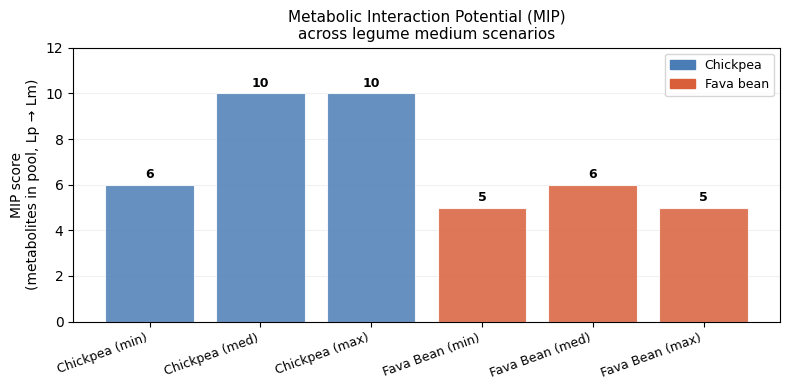

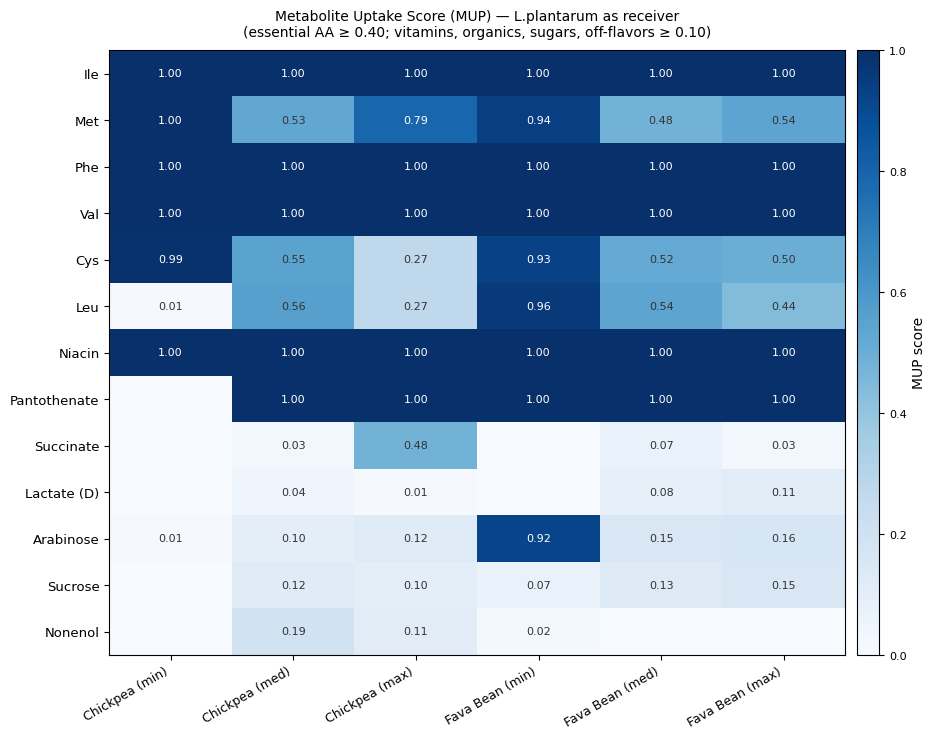

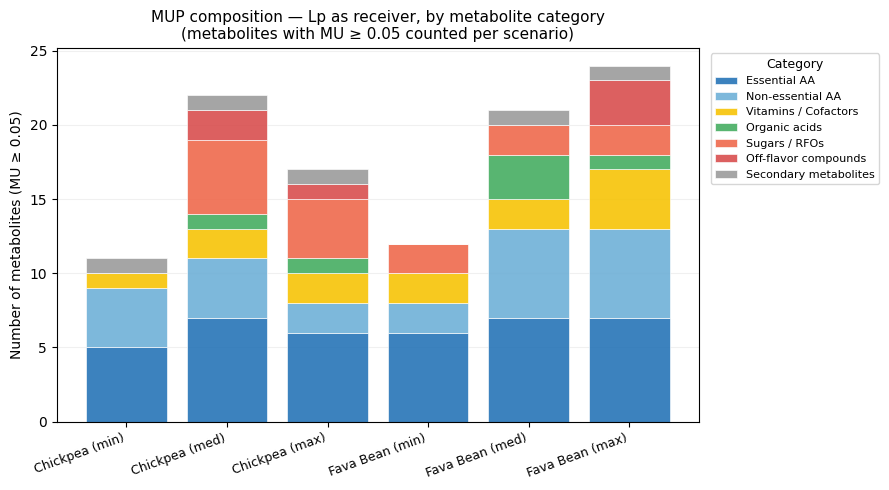

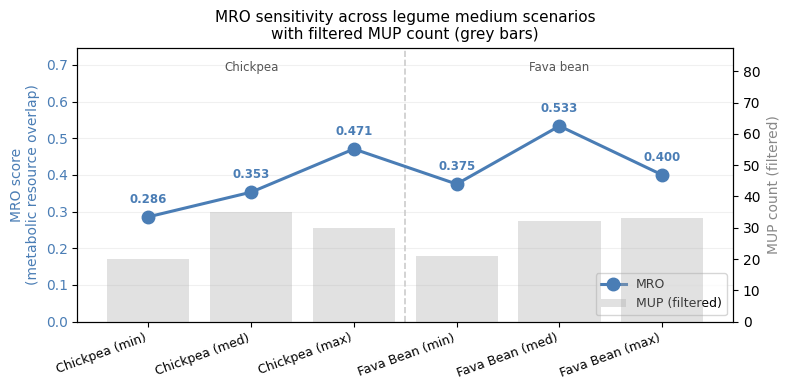

All 4 figures saved to ../results/


In [18]:
import matplotlib.patches as mpatches

CATEGORIES_ORDER = [
    'essential_aa', 'nonessential_aa', 'vitamins_cofactors',
    'organic_acids', 'sugars_rfo', 'off_flavors',
    'nucleotides', 'n_secondary', 'other',
]

CAT_LABELS = {
    'essential_aa'      : 'Essential AA',
    'nonessential_aa'   : 'Non-essential AA',
    'vitamins_cofactors': 'Vitamins / Cofactors',
    'organic_acids'     : 'Organic acids',
    'sugars_rfo'        : 'Sugars / RFOs',
    'off_flavors'       : 'Off-flavor compounds',
    'nucleotides'       : 'Nucleotides',
    'n_secondary'       : 'Secondary metabolites',
    'other'             : 'Other',
}

CAT_COLORS = {
    'essential_aa'      : '#D1E8F7',
    'nonessential_aa'   : '#BEE0F5',
    'vitamins_cofactors': '#FFF3CD',
    'organic_acids'     : '#D4EDDA',
    'sugars_rfo'        : '#F8D7DA',
    'off_flavors'       : '#F5C6CB',
    'nucleotides'       : '#E2D9F3',
    'n_secondary'       : '#D6D6D6',
    'other'             : '#EEEEEE',
}

CATEGORIES = {
    'essential_aa'      : {'ile__L', 'leu__L', 'val__L', 'phe__L', 'trp__L',
                           'met__L', 'thr__L', 'lys__L', 'his__L', 'cys__L'},
    'nonessential_aa'   : {'glu__L', 'gln__L', 'asp__L', 'asn__L', 'pro__L',
                           'ser__L', 'ala__L', 'gly', 'tyr__L', 'arg__L'},
    'vitamins_cofactors': {'pnto__R', 'nac', 'nmn', 'btn', 'fol',
                           'ribflv', 'thm', 'pydxn', '4abz'},
    'organic_acids'     : {'etoh', 'lac__D', 'lac__L', 'ac', 'for',
                           'succ', 'actn__R', 'pyr'},
    'sugars_rfo'        : {'glc__D', 'fru', 'gal', 'sucr', 'malt',
                           'raffin', 'arab__L', 'man'},
    'off_flavors'       : {'hxa', 'hxol', 'nnl', 'nnol',
                           '2mbal', '3mbal', 'ibutld', 'pacald',
                           '2mba', '3mba', '2mpa', 'phenol'},
    'n_secondary'       : {'2hxic__L'},
    'nucleotides'       : {'ade', 'gua', 'ura', 'thymd', 'ins', 'hxan'},
}

SCENARIOS     = list(df_scores.index)
COL_CP        = '#4A7DB5'
COL_FB        = '#D95F3B'
COL_GRID      = '#F0F0F0'
SCENARIO_COLS = [COL_CP, COL_CP, COL_CP, COL_FB, COL_FB, COL_FB]

os.makedirs('../results', exist_ok=True)

# Figure 1: MIP bar plot
fig1, ax1 = plt.subplots(figsize=(8, 4))

mip_vals = df_scores['MIP'].values
bars = ax1.bar(SCENARIOS, mip_vals, color=SCENARIO_COLS, alpha=0.85,
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, mip_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             str(int(val)), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('MIP score\n(metabolites in pool, Lp → Lm)', fontsize=10)
ax1.set_title('Metabolic Interaction Potential (MIP)\nacross legume medium scenarios', fontsize=11)
ax1.set_xticks(range(len(SCENARIOS)))
ax1.set_xticklabels(SCENARIOS, rotation=20, ha='right', fontsize=9)
ax1.yaxis.grid(True, color=COL_GRID, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.set_ylim(0, max(mip_vals) * 1.2)

patches = [mpatches.Patch(color=COL_CP, label='Chickpea'),
           mpatches.Patch(color=COL_FB, label='Fava bean')]
ax1.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.savefig('../results/smetana_01_mip_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: MU heatmap
RELEVANT_CATS = {
    'essential_aa', 'vitamins_cofactors', 'off_flavors',
    'organic_acids', 'sugars_rfo',
}

# Higher threshold for non-vitamins to keep only meaningful entries
MU_THRESHOLD = {
    'essential_aa'      : 0.40,
    'vitamins_cofactors': 0.10,
    'organic_acids'     : 0.10,
    'sugars_rfo'        : 0.10,
    'off_flavors'       : 0.10,
}

def get_cat_for_met(met):
    for cat, members in CATEGORIES.items():
        if met in members:
            return cat
    return 'other'

mu_matrix = {}
for sid, scores in smetana_results.items():
    label = SCENARIO_LABELS[sid]
    mu    = scores['mu']
    for org, mets in mu.items():
        if not mets or 'plantarum' not in org.lower():
            continue
        for m, v in mets.items():
            if v > 0 and m not in ARTEFACTOS:
                met_clean = m.replace('M_', '').replace('_e', '')
                if met_clean not in mu_matrix:
                    mu_matrix[met_clean] = {}
                mu_matrix[met_clean][label] = round(v, 3)

mu_df = pd.DataFrame(mu_matrix).T.reindex(columns=SCENARIOS).fillna(0)

mu_df['_cat'] = [get_cat_for_met(m) for m in mu_df.index]
mu_df['_max'] = mu_df[SCENARIOS].max(axis=1)
mu_df['_cat_order'] = [CATEGORIES_ORDER.index(c) if c in CATEGORIES_ORDER
                       else len(CATEGORIES_ORDER)
                       for c in mu_df['_cat']]

# Apply per-category threshold
def passes_threshold(row):
    cat   = row['_cat']
    thresh = MU_THRESHOLD.get(cat, 1.1)
    return row['_max'] >= thresh and cat in RELEVANT_CATS

mu_df = mu_df[mu_df.apply(passes_threshold, axis=1)]
mu_df = mu_df.sort_values(['_cat_order', '_max'], ascending=[True, False])
mu_df = mu_df.drop(columns=['_cat', '_max', '_cat_order'])

DISPLAY_LABELS = {
    'ile__L': 'Ile', 'phe__L': 'Phe', 'val__L': 'Val',
    'met__L': 'Met', 'cys__L': 'Cys', 'leu__L': 'Leu',
    'thr__L': 'Thr',
    'nac':     'Niacin', 'pnto__R': 'Pantothenate',
    'lac__D':  'Lactate (D)', 'etoh': 'Ethanol',
    'succ':    'Succinate',   'ac':   'Acetate',
    'sucr':    'Sucrose',     'arab__L': 'Arabinose',
    'glc__D':  'Glucose',    'malt': 'Maltose',
    'raffin':  'Raffinose',
    'nnol':    'Nonenol',     'nnl':  'Nonenal',
    '3mba':    '3-Methylbutanoate',
    '2mba':    '2-Methylbutanoate',
    '2mpa':    '2-Methylpropanoate',
}

mu_df.index = [DISPLAY_LABELS.get(m, m) for m in mu_df.index]

def get_cat_from_display(label):
    reverse = {v: k for k, v in DISPLAY_LABELS.items()}
    met_id  = reverse.get(label, label)
    return get_cat_for_met(met_id)

row_colors = [CAT_COLORS.get(get_cat_from_display(m), '#EEEEEE')
              for m in mu_df.index]

n_rows = len(mu_df)
n_rows = len(mu_df)
fig2, ax2 = plt.subplots(figsize=(11, n_rows * 0.45 + 2.0))

im = ax2.imshow(mu_df.values, aspect='auto', cmap='Blues',
                vmin=0, vmax=1, interpolation='nearest')

ax2.set_xticks(range(len(SCENARIOS)))
ax2.set_xticklabels(SCENARIOS, rotation=30, ha='right', fontsize=9)
ax2.set_yticks(range(n_rows))
ax2.set_yticklabels(mu_df.index, fontsize=9.5)

for yi in range(n_rows):
    for xi in range(len(SCENARIOS)):
        val = mu_df.values[yi, xi]
        if val >= 0.01:
            ax2.text(xi, yi, f'{val:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if val > 0.6 else '#333')

from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(ax2)
cbar_ax = divider.append_axes("right", size="3%", pad=0.12)
cbar = fig2.colorbar(im, cax=cbar_ax, label='MUP score')
cbar.ax.tick_params(labelsize=8)

ax2.set_title('Metabolite Uptake Score (MUP) — L.plantarum as receiver\n'
              '(essential AA ≥ 0.40; vitamins, organics, sugars, off-flavors ≥ 0.10)',
              fontsize=10, pad=10)

plt.subplots_adjust(left=0.20)
plt.savefig('../results/smetana_02_mu_heatmap.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: MUS category stacked bar (L.plantarum receiver)
cat_counts = {cat: [] for cat in CATEGORIES_ORDER}

for sid, scores in smetana_results.items():
    mu = scores['mu']
    counts = {cat: 0 for cat in CATEGORIES_ORDER}
    for org, mets in mu.items():
        if not mets or 'plantarum' not in org.lower():
            continue
        for m, v in mets.items():
            if v > 0 and m not in ARTEFACTOS:
                met_clean = m.replace('M_', '').replace('_e', '')
                cat       = 'other'
                for c, members in CATEGORIES.items():
                    if met_clean in members:
                        cat = c
                        break
                if v >= 0.05:   # only count metabolites with MU ≥ 0.05
                    counts[cat] += 1
    for cat in CATEGORIES_ORDER:
        cat_counts[cat].append(counts[cat])

CAT_PALETTE = {
    'essential_aa'     : '#2171B5',
    'nonessential_aa'  : '#6BAED6',
    'vitamins_cofactors': '#F6C200',
    'organic_acids'    : '#41AB5D',
    'sugars_rfo'       : '#EF6548',
    'off_flavors'      : '#D84A4A',
    'nucleotides'      : '#9E7FD0',
    'n_secondary'      : '#999999',
    'other'            : '#CCCCCC',
}

fig3, ax3 = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(SCENARIOS))

for cat in CATEGORIES_ORDER:
    vals = np.array(cat_counts[cat], dtype=float)
    if vals.sum() == 0:
        continue
    ax3.bar(SCENARIOS, vals, bottom=bottom,
            color=CAT_PALETTE[cat], label=CAT_LABELS[cat],
            alpha=0.88, edgecolor='white', linewidth=0.5)
    bottom += vals

ax3.set_ylabel('Number of metabolites (MU ≥ 0.05)', fontsize=10)
ax3.set_title('MUP composition — Lp as receiver, by metabolite category\n'
              '(metabolites with MU ≥ 0.05 counted per scenario)',
              fontsize=11)
ax3.set_xticks(range(len(SCENARIOS)))
ax3.set_xticklabels(SCENARIOS, rotation=20, ha='right', fontsize=9)
ax3.yaxis.grid(True, color=COL_GRID, linewidth=0.8)
ax3.set_axisbelow(True)
ax3.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8,
           title='Category', title_fontsize=9)

plt.tight_layout()
plt.savefig('../results/smetana_03_mip_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: MRO sensitivity across scenarios
fig4, ax4 = plt.subplots(figsize=(8, 4))

mro_vals = df_scores['MRO'].values
mu_filt  = df_scores['MU (filtered)'].values

ax4_twin = ax4.twinx()

ax4.plot(SCENARIOS, mro_vals, 'o-', color=COL_CP,
         linewidth=2.2, markersize=9, zorder=4, label='MRO')
ax4_twin.bar(SCENARIOS, mu_filt, color='#AAAAAA', alpha=0.35,
             label='MUP (filtered)', zorder=2)

for xi, (mro, mu_f) in enumerate(zip(mro_vals, mu_filt)):
    ax4.annotate(f'{mro:.3f}', (xi, mro),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=8.5, color=COL_CP, fontweight='bold')

ax4.set_ylabel('MRO score\n(metabolic resource overlap)', fontsize=10, color=COL_CP)
ax4_twin.set_ylabel('MUP count (filtered)', fontsize=10, color='#888')
ax4.set_title('MRO sensitivity across legume medium scenarios\n'
              'with filtered MUP count (grey bars)', fontsize=11)
ax4.set_xticks(range(len(SCENARIOS)))
ax4.set_xticklabels(SCENARIOS, rotation=20, ha='right', fontsize=9)
ax4.yaxis.grid(True, color=COL_GRID, linewidth=0.8)
ax4.set_axisbelow(True)
ax4.set_ylim(0, max(mro_vals) * 1.4)
ax4_twin.set_ylim(0, max(mu_filt) * 2.5)
ax4.tick_params(axis='y', labelcolor=COL_CP)

# Vertical separator chickpea / fava bean
ax4.axvline(2.5, color='#CCCCCC', linewidth=1.2, linestyle='--')
ax4.text(1.0, max(mro_vals) * 1.28, 'Chickpea',
         ha='center', fontsize=8.5, color='#555')
ax4.text(4.0, max(mro_vals) * 1.28, 'Fava bean',
         ha='center', fontsize=8.5, color='#555')

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../results/smetana_04_mro_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

print('All 4 figures saved to ../results/')

## 9. Interpretation (cross-feeding and the off-flavor mitigation mechanism)

Two amino acid dependencies hold across all six scenarios regardless of medium composition: *L.plantarum* requires uptake of Ile, Phe, and Val at MU=1.00 in every case. This is not incidental - Ile and Val are BCAAs and Phe is the aromatic precursor that feed the Ehrlich pathway directly. A model structurally forced to import these three amino acids in every sampled minimal medium is exactly the substrate pool a competitive BCAA sink would draw from, consistent with the *L.plantarum* as sink mechanism central to this project.

The clearest direct evidence for the *L.mesenteroides*→*L.plantarum* cross-feeding step is the recurring uptake of the Ehrlich acids by *L.plantarum*: 2-methylbutanoate, 3-methylbutanoate and 2-methylpropanoate appear in three of six scenarios — chickpea (med) (2mba 0.08, 2mpa 0.04, 3mba 0.02), fava bean (med) (3mba 0.03, 2mpa 0.01, 2mba 0.01), and fava bean (max) (2mba 0.07, 3mba 0.06, 2mpa 0.05). *L.plantarum* has no Ehrlich decarboxylation capacity of its own, so the only source of these acids in the shared pool is *L.mesenteroides* secretion. These values fall below the 0.10 display threshold used in the MUP heatmap (Figure 2), so the signal is visible only in the raw
printout, not in the figure — worth stating explicitly so the absence from the heatmap isn't read as absence of evidence.

Pantothenate and niacin show MUP = 1.00 for *L.plantarum* in five of six scenarios, consistent with documented pantothenate/niacin auxotrophy in *Lactiplantibacillus*. This result has not been independently verified by direct FBA the way the SC=1.0 result was and should be read as plausible rather than confirmed - `mu_score` samples under the same artificially low `min_growth` threshold that produced a false
positive there.

## 10. Configurations selection for downstream simulation

The maximum-nutrient scenario — chickpea (max) and fava bean (max) — is the configuration carried forward, following the canonical reference
already established: solo growth was validated and fixed at the max scenario there and SMETANA/MICOM use that same reference throughout the project rather than introducing a second baseline.

For each matrix, three initial abundance ratios are tested in the MICOM community simulation: Lp75:Lm25, Lp50:Lm50 and Lp25:Lm75.

## 11. Interpretation & Limitations

The community of *L.plantarum* (iLP728_curated_v2) and *L.mesenteroides* (Koduru2022_curated_v2) was evaluated under six legume medium scenarios (chickpea/fava bean × min/med/max). Chickpea (max) and fava bean (max) are the two configurations carried forward to MICOM,
consistent with the canonical reference established previously.

Two of the five SMETANA scores used here required correction before they could support any biological claim. SC=1.0 for Lp→Lm initially read as absolute growth dependency; direct FBA verification showed *L.plantarum* reaches the same growth rate with all of *L.mesenteroides*'s reactions forced to zero (0.4751 h⁻¹) as with *L.mesenteroides* active (0.47507 h⁻¹) — the score is a construction artefact, not a real dependency. The root cause is methodological: `sc_score` tests feasibility only at an artificially low `min_growth` threshold (10% of the slower organism), not at the organism's actual achievable growth rate. The same threshold underlies the unverified pantothenate/niacin signal, which is reported as plausible rather than confirmed for this reason. 

The evidence supports the project's central off-flavor mitigation mechanism. *L.plantarum* is structurally forced to
import Ile, Phe and Val — the BCAA/aromatic substrates that feed the Ehrlich pathway — in every one of the six scenarios, consistent with *L.plantarum* acting as a competitive sink for these amino acids. *L.plantarum* also takes up the Ehrlich acids 2-methylbutanoate, 3-methylbutanoate and 2-methylpropanoate in three of six scenarios. Since *L.plantarum* has no Ehrlich decarboxylation capacity of its own, the only source of these acids in the shared pool is *L.mesenteroides* secretion, making this the direct SMETANA level evidence for the *L.mesenteroides*→*L.plantarum* cross-feeding step. 

MIP and MRO are unaffected by the corrections above and remain usable as reported: MIP ranges from 5–6 (fava bean) to 6–10
(chickpea) and MRO peaks at 0.4706–0.5333 depending on scenario, indicating partial but not complete resource overlap between the two
species in every medium tested.

## 12. Bibliography

1. Zelezniak, A., Andrejev, S., Ponomarova, O., Mende, D. R., Bork, P., & Patil, K. R. (2015). Metabolic dependencies drive species co-occurrence in diverse microbial communities. Proceedings of the National Academy of Sciences, 112(20), 6449–6454. https://doi.org/10.1073/pnas.1421834112

2. Machado, D. SMETANA: Species METabolic interaction ANAlysis (v1.2.1). GitHub repository. https://github.com/cdanielmachado/smetana. Implementation detail confirming MPS is computed as a binary score, not the graded measure described in [1]: cdanielmachado/smetana, Issue #14, https://github.com/cdanielmachado/smetana/issues/14 (accessed May 2026).

